# Module 4: Classical Time Series Models (ETS, SARIMAX)

This notebook fits **classical** forecasting models on a *small SKU sample* and compares them to baselines.

Why a sample?
- ETS/SARIMAX are typically fit per SKU and can be slow/fragile at large scale.

## What you'll do
- Load feature-ready dataset from Module 2
- Create a time-based split (same idea as Module 3)
- Fit ETS and SARIMAX per SKU (sample)
- Evaluate with MAE/RMSE/WAPE/sMAPE
- Run residual diagnostics (ACF + Ljung–Box)
- Save a comparison report


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../')

from src.models.baseline import naive_forecast, moving_average_forecast
from src.models.classical import ets_holt_winters_forecast, sarimax_forecast, sarimax_fit_residuals
from src.evaluation.metrics import mae, rmse, wape, smape

import matplotlib.pyplot as plt

print('Imports OK')


Imports OK


## Load data

We use the feature-ready dataset created in Module 2:
- `data/processed/featured_sales_data.csv`


In [2]:
data_path_candidates = [
    Path('../data/processed/featured_sales_data.csv'),
    Path('data/processed/featured_sales_data.csv'),
]

data_path = next((p for p in data_path_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find featured_sales_data.csv. Run Module 2 to generate it: notebooks/02_data_cleaning.ipynb"
    )

df = pd.read_csv(data_path, parse_dates=['date'])
print(f"Loaded: {data_path}")
print(df.shape)
df.head()


Loaded: ..\data\processed\featured_sales_data.csv
(361500, 65)


,sku_id,date,category,subcategory,price,units_sold,revenue,promotion_flag,stock_available,year,...,price_rolling_mean_7,price_relative_to_avg_7,price_rolling_mean_30,price_relative_to_avg_30,price_rolling_std_7,month_day_interaction,holiday_weekend,promo_weekend,is_peak_period,quarter_day_interaction
0,SKU001,2023-12-24,Electronics,Accessories,168.81,28,4726.68,0,108,2023,...,157.494286,1.071848,157.220000,1.073718,14.218150,72,1,0,1,24
1,SKU001,2023-12-25,Electronics,Accessories,167.59,20,3351.89,0,6,2023,...,158.820000,1.055220,158.372222,1.058203,14.730299,0,0,0,0,0
2,SKU001,2023-12-26,Electronics,Accessories,165.31,22,3636.74,0,198,2023,...,164.227143,1.006594,159.066000,1.039254,5.097391,12,0,0,0,4
3,SKU001,2023-12-27,Electronics,Accessories,164.80,46,7580.63,0,52,2023,...,165.731429,0.994380,159.587273,1.032664,2.621821,24,0,0,0,8
4,SKU001,2023-12-28,Electronics,Accessories,131.47,33,4338.57,1,123,2023,...,161.214286,0.815498,157.244167,0.836088,13.324664,36,0,0,0,12


## Define split and SKU sample

We’ll forecast the next `HORIZON` days after a cutoff date.

Because classical models are slower, we’ll fit them on a sample of SKUs:
- 5 top-volume SKUs
- 5 random SKUs


In [3]:
SKU_COL = 'sku_id'
DATE_COL = 'date'
TARGET_COL = 'units_sold'

HORIZON = 14
max_date = df[DATE_COL].max()
cutoff = max_date - pd.Timedelta(days=HORIZON)

train = df[df[DATE_COL] <= cutoff].copy()
test = df[(df[DATE_COL] > cutoff) & (df[DATE_COL] <= cutoff + pd.Timedelta(days=HORIZON))].copy()

# SKU sample
sku_volume = train.groupby(SKU_COL)[TARGET_COL].sum().sort_values(ascending=False)
top_skus = sku_volume.head(5).index.tolist()
all_skus = train[SKU_COL].unique()
np.random.seed(42)
rand_skus = np.random.choice([s for s in all_skus if s not in top_skus], size=5, replace=False).tolist()

sku_sample = top_skus + rand_skus
print('Cutoff:', cutoff.date(), 'Horizon:', HORIZON)
print('SKU sample:', sku_sample)


Cutoff: 2025-12-01 Horizon: 14
SKU sample: ['SKU484', 'SKU435', 'SKU442', 'SKU397', 'SKU014', 'SKU461', 'SKU075', 'SKU312', 'SKU177', 'SKU335']


## Fit models per SKU and score

We’ll compare:
- Baselines: naive, moving average (7)
- Classical: ETS (weekly seasonality), SARIMAX (weekly seasonality)

We’ll compute metrics per SKU and overall.


In [4]:
def score_one_sku(sku: str):
    g_train = train[train[SKU_COL] == sku].sort_values(DATE_COL)
    g_test = test[test[SKU_COL] == sku].sort_values(DATE_COL)

    y_train = g_train[TARGET_COL].to_numpy(dtype=float)
    y_true = g_test[TARGET_COL].to_numpy(dtype=float)

    # Baselines
    y_pred_naive = naive_forecast(y_train, horizon=HORIZON).y_pred
    y_pred_ma7 = moving_average_forecast(y_train, horizon=HORIZON, window=7).y_pred

    # Classical
    try:
        y_pred_ets = ets_holt_winters_forecast(y_train, horizon=HORIZON, seasonal_periods=7).y_pred
    except Exception:
        y_pred_ets = np.full(HORIZON, np.nan)

    try:
        y_pred_sarimax = sarimax_forecast(y_train, horizon=HORIZON, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)).y_pred
    except Exception:
        y_pred_sarimax = np.full(HORIZON, np.nan)

    def _metrics(y_pred):
        if np.any(np.isnan(y_pred)):
            return {'MAE': np.nan, 'RMSE': np.nan, 'WAPE': np.nan, 'sMAPE': np.nan}
        return {
            'MAE': mae(y_true, y_pred),
            'RMSE': rmse(y_true, y_pred),
            'WAPE': wape(y_true, y_pred),
            'sMAPE': smape(y_true, y_pred),
        }

    rows = []
    for method, y_pred in [
        ('naive', y_pred_naive),
        ('moving_average_7', y_pred_ma7),
        ('ets_hw_7', y_pred_ets),
        ('sarimax_111_111_7', y_pred_sarimax),
    ]:
        m = _metrics(y_pred)
        m.update({'sku_id': sku, 'method': method})
        rows.append(m)

    return pd.DataFrame(rows)

per_sku_scores = pd.concat([score_one_sku(s) for s in sku_sample], ignore_index=True)
per_sku_scores


,MAE,RMSE,WAPE,sMAPE,sku_id,method
0,20.785714,30.032126,0.243108,0.302174,SKU484,naive
1,23.602041,30.770546,0.276047,0.346717,SKU484,moving_average_7
2,19.868301,28.894137,0.232378,0.296981,SKU484,ets_hw_7
3,20.919500,28.830269,0.244673,0.312121,SKU484,sarimax_111_111_7
4,35.000000,46.687410,0.486111,0.595037,SKU435,naive
5,33.714286,41.889310,0.468254,0.647656,SKU435,moving_average_7
6,31.438799,43.576402,0.436650,0.571817,SKU435,ets_hw_7
7,30.837471,41.052365,0.428298,0.581464,SKU435,sarimax_111_111_7
8,36.142857,48.685580,0.470260,0.518393,SKU442,naive
9,30.265306,38.867646,0.393787,0.494731,SKU442,moving_average_7


In [5]:
# Overall comparison (average across sampled SKUs)
overall = per_sku_scores.groupby('method')[['MAE','RMSE','WAPE','sMAPE']].mean().sort_values('WAPE')
overall


,MAE,RMSE,WAPE,sMAPE
method,,,,
ets_hw_7,22.417777,31.238226,0.364170,0.460904
sarimax_111_111_7,22.665868,30.561153,0.366130,0.473789
moving_average_7,24.481633,31.514381,0.405846,0.506887
naive,25.342857,33.598647,0.429352,0.510991


## Residual diagnostics (SARIMAX)

We’ll fit SARIMAX on one SKU and inspect residuals:
- residual series
- ACF plot
- Ljung–Box test

If residuals show strong autocorrelation, the model is missing structure.


Diagnostics SKU: SKU484
Residuals mean: 1.017 std: 32.069


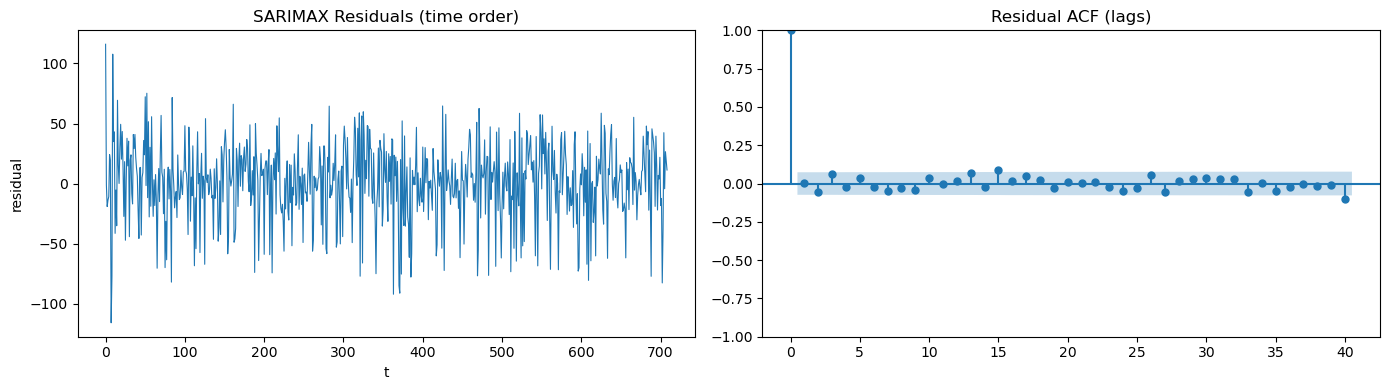

,lb_stat,lb_pvalue
7,8.125391,0.321667
14,15.187795,0.365439
21,24.497070,0.269602
28,32.025624,0.273469


In [6]:
diag_sku = sku_sample[0]
y_train = train[train[SKU_COL] == diag_sku].sort_values(DATE_COL)[TARGET_COL].to_numpy(dtype=float)

fit, resid = sarimax_fit_residuals(y_train, order=(1,1,1), seasonal_order=(1,1,1,7))
print('Diagnostics SKU:', diag_sku)
print('Residuals mean:', np.mean(resid).round(4), 'std:', np.std(resid).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(resid, linewidth=0.8)
axes[0].set_title('SARIMAX Residuals (time order)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('residual')

# ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid, ax=axes[1], lags=40)
axes[1].set_title('Residual ACF (lags)')

plt.tight_layout()
plt.show()

# Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[7, 14, 21, 28], return_df=True)
lb


In [7]:
# Save reports
out_dir = Path('../outputs/reports')
out_dir.mkdir(parents=True, exist_ok=True)

per_sku_out = out_dir / 'module4_classical_per_sku_metrics.csv'
per_sku_scores.to_csv(per_sku_out, index=False)
print('Saved:', per_sku_out)

overall_out = out_dir / 'module4_classical_summary.csv'
overall.reset_index().to_csv(overall_out, index=False)
print('Saved:', overall_out)


Saved: ..\outputs\reports\module4_classical_per_sku_metrics.csv
Saved: ..\outputs\reports\module4_classical_summary.csv
